In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

dataset_path = "/content/drive/MyDrive/AMR_dataset/train"

In [3]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [4]:
img_size = (224, 224)
batch_size = 16

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 360 images belonging to 3 classes.
Found 90 images belonging to 3 classes.


In [5]:
cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten()
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model_input_shape = (224, 224, 3)

def extract_features(generator):
    features = []
    labels = []

    for i in range(len(generator)):
        x, y = generator[i]
        f = cnn.predict(x)
        features.append(f)
        labels.append(y)

    return np.vstack(features), np.vstack(labels)

X_train, y_train = extract_features(train_data)
X_val, y_val = extract_features(val_data)

# Reshape for LSTM
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [7]:
lstm_model = models.Sequential([
    layers.LSTM(128, input_shape=(1, X_train.shape[2]), return_sequences=False),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 678ms/step - accuracy: 0.7139 - loss: 0.6971 - val_accuracy: 1.0000 - val_loss: 0.3361
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 660ms/step - accuracy: 0.9417 - loss: 0.3151 - val_accuracy: 1.0000 - val_loss: 0.1703
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 637ms/step - accuracy: 0.9861 - loss: 0.1797 - val_accuracy: 1.0000 - val_loss: 0.0919
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 598ms/step - accuracy: 1.0000 - loss: 0.1078 - val_accuracy: 1.0000 - val_loss: 0.0537
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 644ms/step - accuracy: 1.0000 - loss: 0.0759 - val_accuracy: 1.0000 - val_loss: 0.0322
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 593ms/step - accuracy: 1.0000 - loss: 0.0555 - val_accuracy: 1.0000 - val_loss: 0.0211
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 630ms/step - accuracy: 1.0000 - loss: 0.0373 - val_accuracy: 1.0000 - val_loss: 0.0150
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 619ms/step - accuracy: 1.0000 - loss: 0.0317 - val_accu

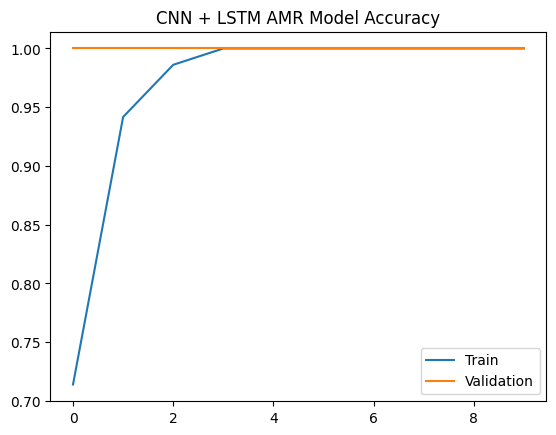

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("CNN + LSTM AMR Model Accuracy")
plt.show()

In [13]:
loss, acc = lstm_model.evaluate(X_val, y_val)
print("Validation Accuracy:", acc)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.0064
Validation Accuracy: 1.0
